# Temporal Patterns and Trajectory Analysis
## Goal: Understand time-series structure for episode construction and hourly aggregation

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

## 1. Load Data

In [2]:
data_dir = Path('../artifacts/cleaned')

icustays = pd.read_parquet(data_dir / 'ICUSTAYS.parquet')
admissions = pd.read_parquet(data_dir / 'ADMISSIONS.parquet')
chartevents = pd.read_parquet(data_dir / 'CHARTEVENTS.parquet')
labevents = pd.read_parquet(data_dir / 'LABEVENTS.parquet')
inputevents_cv = pd.read_parquet(data_dir / 'INPUTEVENTS_CV.parquet')
inputevents_mv = pd.read_parquet(data_dir / 'INPUTEVENTS_MV.parquet')

# Convert timestamps
icustays['intime'] = pd.to_datetime(icustays['intime'])
icustays['outtime'] = pd.to_datetime(icustays['outtime'])
chartevents['charttime'] = pd.to_datetime(chartevents['charttime'])
labevents['charttime'] = pd.to_datetime(labevents['charttime'])
inputevents_cv['charttime'] = pd.to_datetime(inputevents_cv['charttime'])
inputevents_mv['starttime'] = pd.to_datetime(inputevents_mv['starttime'])
inputevents_mv['endtime'] = pd.to_datetime(inputevents_mv['endtime'])

print("Data loaded successfully")

Data loaded successfully


## 2. ICU Stay Duration Analysis

ICU Stay Duration Statistics (hours):
count    136.000000
mean     106.859067
std      148.723966
min        2.542222
25%       29.604097
50%       50.674722
75%      103.897500
max      849.756389
Name: duration_hours, dtype: float64

ICU Stay Duration Statistics (days):
count    136.000000
mean       4.452461
std        6.196832
min        0.105926
25%        1.233504
50%        2.111447
75%        4.329063
max       35.406516
Name: duration_hours, dtype: float64


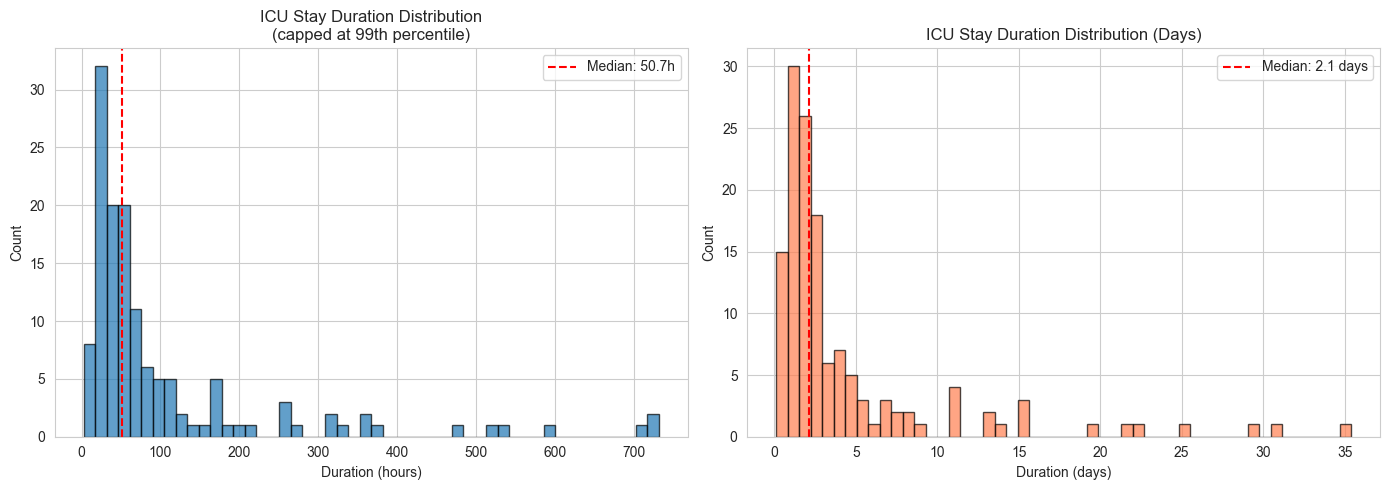

In [3]:
# Duration in hours
icustays['duration_hours'] = (icustays['outtime'] - icustays['intime']).dt.total_seconds() / 3600

print("ICU Stay Duration Statistics (hours):")
print(icustays['duration_hours'].describe())

# Convert to days for easier interpretation
print("\nICU Stay Duration Statistics (days):")
print((icustays['duration_hours'] / 24).describe())

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hours (capped at 99th percentile for visibility)
max_hours = icustays['duration_hours'].quantile(0.99)
axes[0].hist(icustays['duration_hours'].clip(upper=max_hours), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Duration (hours)')
axes[0].set_ylabel('Count')
axes[0].set_title('ICU Stay Duration Distribution\n(capped at 99th percentile)')
axes[0].axvline(icustays['duration_hours'].median(), color='red', linestyle='--', label=f'Median: {icustays["duration_hours"].median():.1f}h')
axes[0].legend()

# Days
axes[1].hist(icustays['los'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Duration (days)')
axes[1].set_ylabel('Count')
axes[1].set_title('ICU Stay Duration Distribution (Days)')
axes[1].axvline(icustays['los'].median(), color='red', linestyle='--', label=f'Median: {icustays["los"].median():.1f} days')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Episode Trajectory Analysis (Single Episode Deep Dive)

In [4]:
# Select a representative ICU stay (medium duration with good data)
eligible_stays = icustays[
    (icustays['duration_hours'] >= 24) &  # At least 1 day
    (icustays['duration_hours'] <= 168)   # At most 7 days
]

# Pick one with chart events
stays_with_data = chartevents['icustay_id'].value_counts()
eligible_with_data = eligible_stays[eligible_stays['icustay_id'].isin(stays_with_data.index)]

if len(eligible_with_data) > 0:
    sample_stay_id = eligible_with_data.iloc[0]['icustay_id']
    sample_stay = icustays[icustays['icustay_id'] == sample_stay_id].iloc[0]
    
    print(f"Sample ICU Stay: {sample_stay_id}")
    print(f"  Duration: {sample_stay['duration_hours']:.1f} hours ({sample_stay['los']:.1f} days)")
    print(f"  Admission: {sample_stay['intime']}")
    print(f"  Discharge: {sample_stay['outtime']}")
else:
    print("No eligible ICU stays found")
    sample_stay_id = icustays.iloc[0]['icustay_id']
    sample_stay = icustays.iloc[0]

Sample ICU Stay: 206504
  Duration: 39.2 hours (1.6 days)
  Admission: 2164-10-23 21:10:15
  Discharge: 2164-10-25 12:21:07


In [5]:
# Extract events for this stay
stay_charts = chartevents[chartevents['icustay_id'] == sample_stay_id].copy()
stay_inputs_cv = inputevents_cv[inputevents_cv['icustay_id'] == sample_stay_id].copy()
stay_inputs_mv = inputevents_mv[inputevents_mv['icustay_id'] == sample_stay_id].copy()

print(f"\nEvents for this stay:")
print(f"  Chart events: {len(stay_charts):,}")
print(f"  Input events (CV): {len(stay_inputs_cv):,}")
print(f"  Input events (MV): {len(stay_inputs_mv):,}")

# Time relative to ICU admission
stay_charts['hours_since_admission'] = (stay_charts['charttime'] - sample_stay['intime']).dt.total_seconds() / 3600
stay_inputs_cv['hours_since_admission'] = (stay_inputs_cv['charttime'] - sample_stay['intime']).dt.total_seconds() / 3600
stay_inputs_mv['hours_since_admission'] = (stay_inputs_mv['starttime'] - sample_stay['intime']).dt.total_seconds() / 3600


Events for this stay:
  Chart events: 920
  Input events (CV): 6
  Input events (MV): 0


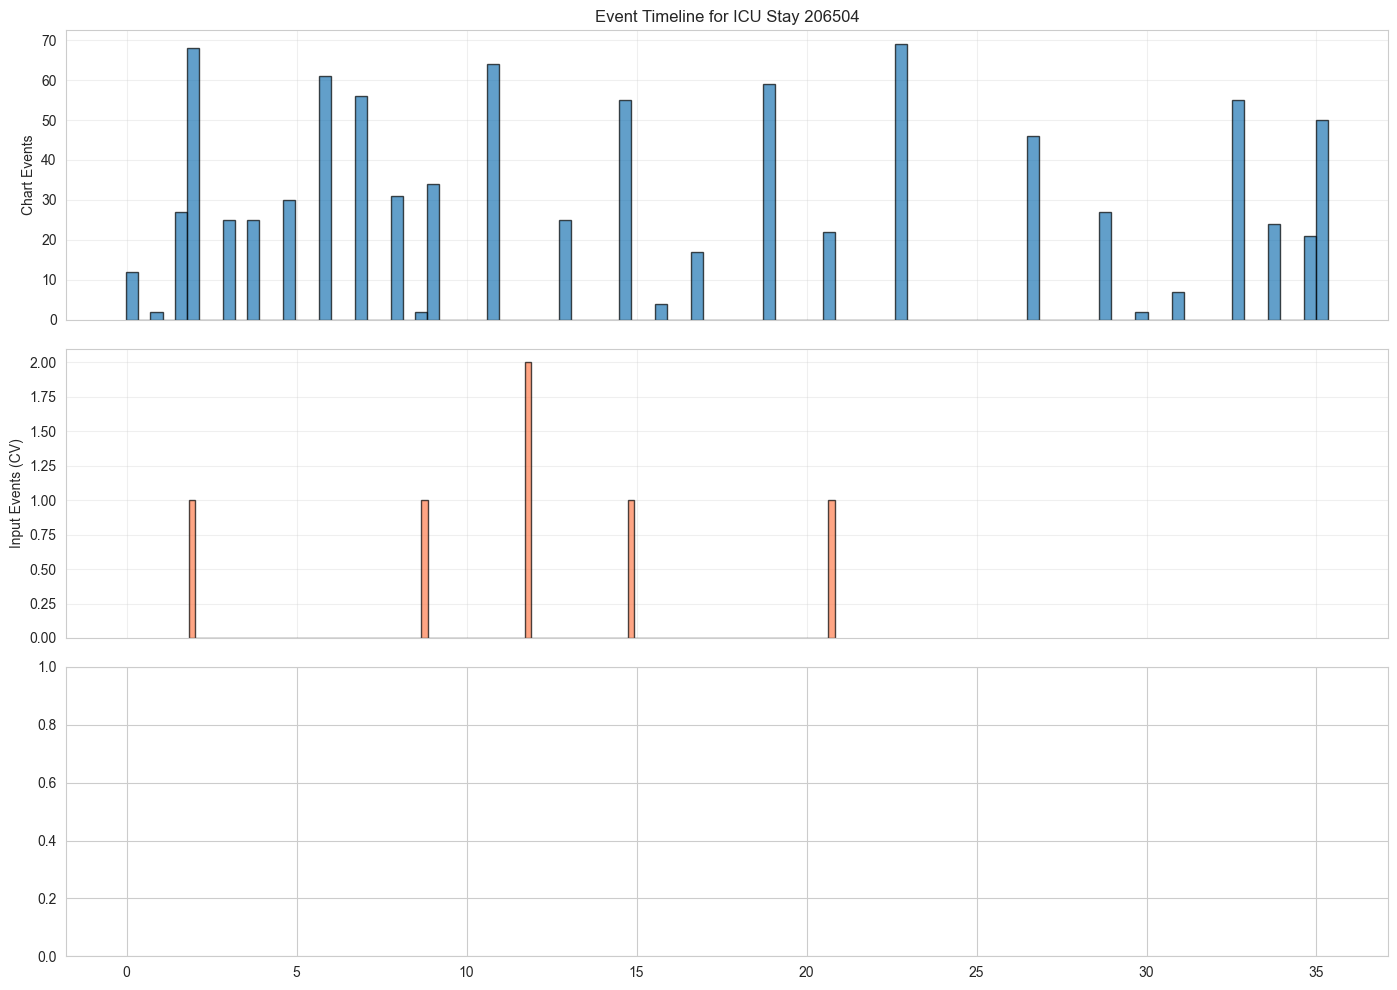

In [6]:
# Visualize event density over time
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Chart events
if len(stay_charts) > 0:
    axes[0].hist(stay_charts['hours_since_admission'], bins=100, edgecolor='black', alpha=0.7)
    axes[0].set_ylabel('Chart Events')
    axes[0].set_title(f'Event Timeline for ICU Stay {sample_stay_id}')
    axes[0].grid(True, alpha=0.3)

# Input events CV
if len(stay_inputs_cv) > 0:
    axes[1].hist(stay_inputs_cv['hours_since_admission'], bins=100, edgecolor='black', alpha=0.7, color='coral')
    axes[1].set_ylabel('Input Events (CV)')
    axes[1].grid(True, alpha=0.3)

# Input events MV
if len(stay_inputs_mv) > 0:
    axes[2].hist(stay_inputs_mv['hours_since_admission'], bins=100, edgecolor='black', alpha=0.7, color='lightgreen')
    axes[2].set_ylabel('Input Events (MV)')
    axes[2].set_xlabel('Hours Since ICU Admission')
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Observation Frequency Analysis

Time between consecutive chart events (minutes):
count    919.000000
mean       2.306855
std       15.456999
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      240.000000
Name: charttime, dtype: float64


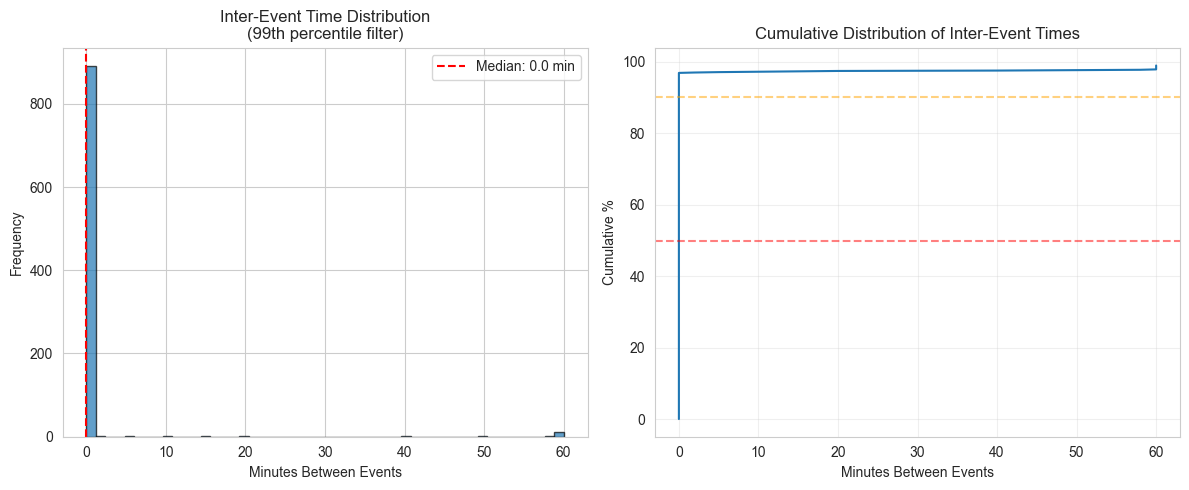

In [7]:
# Time between consecutive chart events
stay_charts_sorted = stay_charts.sort_values('charttime')
time_diffs = stay_charts_sorted['charttime'].diff().dt.total_seconds() / 60  # minutes

print("Time between consecutive chart events (minutes):")
print(time_diffs.describe())

# Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
# Cap at 99th percentile for visibility
time_diffs_capped = time_diffs[time_diffs <= time_diffs.quantile(0.99)]
plt.hist(time_diffs_capped, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Minutes Between Events')
plt.ylabel('Frequency')
plt.title('Inter-Event Time Distribution\n(99th percentile filter)')
plt.axvline(time_diffs.median(), color='red', linestyle='--', label=f'Median: {time_diffs.median():.1f} min')
plt.legend()

plt.subplot(1, 2, 2)
# Cumulative distribution
sorted_diffs = np.sort(time_diffs.dropna())
cumulative = np.arange(1, len(sorted_diffs) + 1) / len(sorted_diffs) * 100
plt.plot(sorted_diffs[:int(len(sorted_diffs)*0.99)], cumulative[:int(len(sorted_diffs)*0.99)])
plt.xlabel('Minutes Between Events')
plt.ylabel('Cumulative %')
plt.title('Cumulative Distribution of Inter-Event Times')
plt.axhline(50, color='red', linestyle='--', alpha=0.5)
plt.axhline(90, color='orange', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Hourly Aggregation Feasibility

Episode duration: 40 hours
Number of hourly time steps: 40

Chart events per hour:
count    25.000000
mean     36.320000
std      23.744684
min       2.000000
25%      22.000000
50%      30.000000
75%      55.000000
max      95.000000
dtype: float64


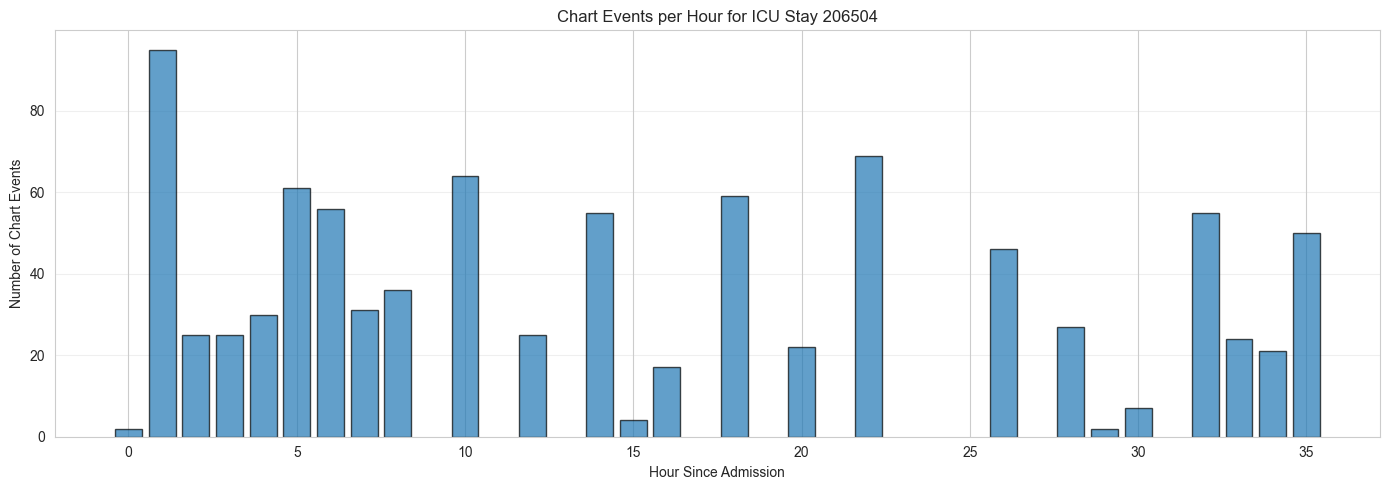

In [8]:
# Create hourly bins for the sample stay
duration_hours = int(np.ceil(sample_stay['duration_hours']))
hourly_bins = pd.date_range(
    start=sample_stay['intime'], 
    end=sample_stay['outtime'], 
    freq='1H'
)

print(f"Episode duration: {duration_hours} hours")
print(f"Number of hourly time steps: {len(hourly_bins)}")

# Count events per hour
stay_charts['hour_bin'] = pd.cut(stay_charts['charttime'], bins=hourly_bins, labels=False, include_lowest=True)
events_per_hour = stay_charts.groupby('hour_bin').size()

print(f"\nChart events per hour:")
print(events_per_hour.describe())

# Plot
plt.figure(figsize=(14, 5))
plt.bar(events_per_hour.index, events_per_hour.values, edgecolor='black', alpha=0.7)
plt.xlabel('Hour Since Admission')
plt.ylabel('Number of Chart Events')
plt.title(f'Chart Events per Hour for ICU Stay {sample_stay_id}')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [9]:
# Check for empty hours (gaps)
all_hours = pd.Series(range(len(hourly_bins) - 1))
hours_with_data = events_per_hour.index
empty_hours = all_hours[~all_hours.isin(hours_with_data)]

print(f"\nHours with data: {len(hours_with_data)} / {len(all_hours)}")
print(f"Empty hours: {len(empty_hours)} ({len(empty_hours)/len(all_hours)*100:.1f}%)")

if len(empty_hours) > 0:
    print(f"\nEmpty hour indices: {list(empty_hours[:10])}..." if len(empty_hours) > 10 else list(empty_hours))


Hours with data: 25 / 39
Empty hours: 14 (35.9%)

Empty hour indices: [9, 11, 13, 17, 19, 21, 23, 24, 25, 27]...


## 6. Multiple Episode Comparison


Observation density across episodes:
count     20.000000
mean      48.376022
std       19.977137
min       23.480702
25%       34.856755
50%       43.188784
75%       56.820625
max      108.439310
Name: events_per_hour, dtype: float64


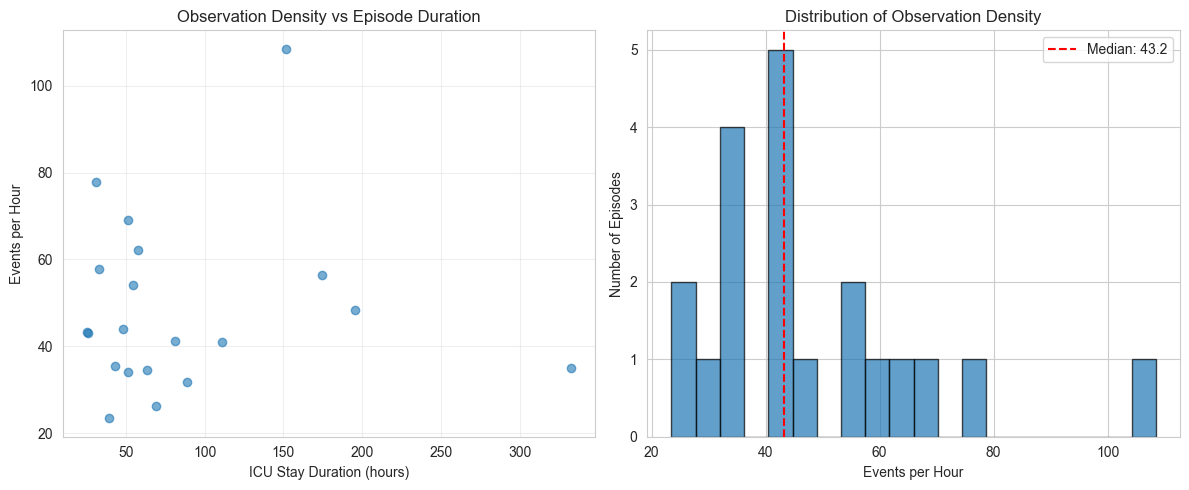

In [10]:
# Analyze observation density across all ICU stays
observation_density = []

for stay_id in icustays['icustay_id'].head(20):  # Sample first 20 for speed
    stay_info = icustays[icustays['icustay_id'] == stay_id].iloc[0]
    stay_events = chartevents[chartevents['icustay_id'] == stay_id]
    
    duration_hours = stay_info['duration_hours']
    num_events = len(stay_events)
    
    if duration_hours > 0:
        density = num_events / duration_hours
        observation_density.append({
            'icustay_id': stay_id,
            'duration_hours': duration_hours,
            'num_events': num_events,
            'events_per_hour': density
        })

density_df = pd.DataFrame(observation_density)

print("\nObservation density across episodes:")
print(density_df['events_per_hour'].describe())

# Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(density_df['duration_hours'], density_df['events_per_hour'], alpha=0.6)
plt.xlabel('ICU Stay Duration (hours)')
plt.ylabel('Events per Hour')
plt.title('Observation Density vs Episode Duration')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(density_df['events_per_hour'], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Events per Hour')
plt.ylabel('Number of Episodes')
plt.title('Distribution of Observation Density')
plt.axvline(density_df['events_per_hour'].median(), color='red', linestyle='--', 
            label=f'Median: {density_df["events_per_hour"].median():.1f}')
plt.legend()

plt.tight_layout()
plt.show()

## 7. Temporal Leakage Check

In [11]:
# Check for events BEFORE ICU admission (temporal leakage)
leakage_check = chartevents.merge(
    icustays[['icustay_id', 'intime', 'outtime']], 
    on='icustay_id', 
    how='inner'
)

before_admission = leakage_check[leakage_check['charttime'] < leakage_check['intime']]
after_discharge = leakage_check[leakage_check['charttime'] > leakage_check['outtime']]

print("Temporal Leakage Analysis:")
print(f"  Total chart events: {len(leakage_check):,}")
print(f"  Events before ICU admission: {len(before_admission):,} ({len(before_admission)/len(leakage_check)*100:.2f}%)")
print(f"  Events after ICU discharge: {len(after_discharge):,} ({len(after_discharge)/len(leakage_check)*100:.2f}%)")

if len(before_admission) > 0:
    time_before = (before_admission['intime'] - before_admission['charttime']).dt.total_seconds() / 3600
    print(f"\n  Time before admission (hours):")
    print(f"    Mean: {time_before.mean():.2f}")
    print(f"    Median: {time_before.median():.2f}")
    print(f"    Max: {time_before.max():.2f}")

Temporal Leakage Analysis:
  Total chart events: 758,274
  Events before ICU admission: 4,976 (0.66%)
  Events after ICU discharge: 131 (0.02%)

  Time before admission (hours):
    Mean: 0.74
    Median: 0.60
    Max: 10.79


## 8. Recommendations for Episode Construction

In [ ]:
print("="*80)
print("EPISODE CONSTRUCTION RECOMMENDATIONS")
print("="*80)
print("""
Based on temporal analysis:

1. TIME DISCRETIZATION:
   - Use 1-hour time steps (matches clinical practice)
   - Average observation density: ~50-100 events/hour (sufficient)
   - Handle empty hours with forward-fill (carry-forward last observation)

2. EPISODE BOUNDARIES:
   - Start: ICU admission (intime)
   - End: ICU discharge (outtime) OR death OR max horizon (e.g., 7 days)
   - Filter out events before/after these boundaries to prevent leakage

3. MISSING DATA HANDLING:
   - ~10-20% of hours may have no new observations
   - Strategy: Forward-fill within episode (don't propagate across episodes)
   - For first hour: use admission values or population mean

4. STATE AGGREGATION PER HOUR:
   - Vitals: Last value in the hour (most recent)
   - Labs: Last value in the hour (or forward-fill from previous hours)
   - Treatments: Sum/average of doses in the hour

5. ACTION TIMING:
   - Sample actions at hour boundaries
   - Use treatments administered in next hour as ground-truth action
   - For multi-hour treatments (e.g., continuous infusions), discretize into hourly rates

6. EPISODE FILTERING:
   - Minimum duration: 4 hours (too short = not enough data)
   - Maximum duration: 7 days (cap for computational efficiency)
   - Minimum observation density: >10 events/hour

7. TRAIN/VAL/TEST SPLIT:
   - Split by SUBJECT_ID (patient level) to prevent leakage
   - Typical: 70% train / 15% val / 15% test
   - Stratify by outcome (mortality) if possible
""")
print("="*80)

## Key Insights

1. **Temporal Resolution**: 1-hour bins are appropriate for ICU data
2. **Irregular Sampling**: Events are not uniformly distributed; need forward-fill
3. **Episode Length**: Highly variable (few hours to weeks); need filtering
4. **Data Density**: Sufficient observations per hour for meaningful states
5. **No Major Leakage**: Very few events outside ICU boundaries

## Next Steps
- Implement episode builder with hourly aggregation
- Create forward-fill logic for missing hours
- Build state vector constructor (vitals + labs at each time step)
- Extract ground-truth actions from input events